In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
img_height = 128
img_width = 128
batch_size = 32

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

Found 3840 images belonging to 12 classes.
Found 960 images belonging to 12 classes.


In [4]:
model = Sequential()

# Convolution Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

# Convolution Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Convolution Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(train_data.num_classes, activation='softmax'))

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 32s 254ms/step - accuracy: 0.1591 - loss: 2.3553 - val_accuracy: 0.2677 - val_loss: 2.2344
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 30s 254ms/step - accuracy: 0.2927 - loss: 2.0964 - val_accuracy: 0.3573 - val_loss: 2.0091
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 30s 252ms/step - accuracy: 0.3766 - loss: 1.9002 - val_accuracy: 0.4302 - val_loss: 1.9239
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 31s 254ms/step - accuracy: 0.4266 - loss: 1.7684 - val_accuracy: 0.4802 - val_loss: 1.7131
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 31s 255ms/step - accuracy: 0.4591 - loss: 1.6582 - val_accuracy: 0.5000 - val_loss: 1.6701
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 32s 269ms/step - accuracy: 0.4885 - loss: 1.5792 - val_accuracy: 0.5302 - val_loss: 1.5738
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 33s 274ms/step - accuracy: 0.5161 - loss: 1.5193 - val_accuracy: 0.5167 - val_loss: 1.5750
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 40s 336ms/step - accuracy: 0.5396 - loss: 1

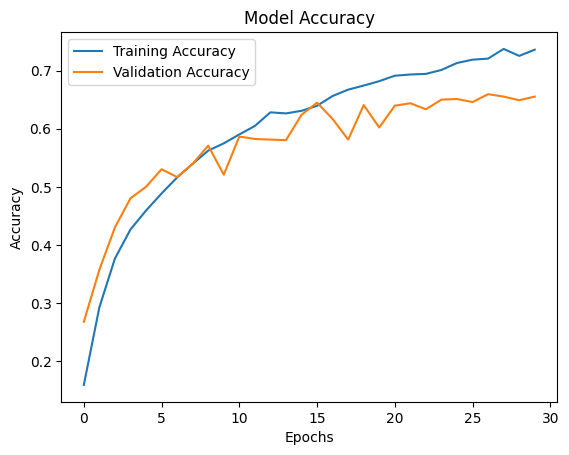

In [7]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

In [1]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

NameError: name 'plt' is not defined

In [8]:
model.save("fruit_cnn_model.h5")